<a href="https://colab.research.google.com/github/navgaur/SP-QM_ML-2025/blob/main/QM_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Summer Students project : June - August 2025**

## **Title : Estimating the energy of a Quantum Mechanical particle using Machine Learning**

## Authors : Ojas Jha, Manjeeta Nath
### Class : B.Sc. (H) Physics 2023-27
### Affiliation: Dept. of Physics, Dyal Singh College (University of Delhi)


### Mentor : Naveen Gaur

---

### Import necessary libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.linalg import eigh_tridiagonal
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from scipy.signal import find_peaks
import seaborn as sns

### Plot the potentials of known systems
This domain is not used for training the linear regression model

In [2]:
N = 100  # Number of grid points
L = 1

In [3]:
hbar = 1
m = 1

In [7]:
def infinite_square_well(x, L):
  V = np.ones(N) * 1e6
  V[(x > -L/2) & (x < L/2)] = 0
  return V/10

def finite_square_well(x, L, V0):
  V = np.ones(N) * V0
  V[(x > 0.8 * (-L/2)) & (x < 0.8 * L/2)] = 0
  return V

def quantum_harmonic_oscillator(x, k):
  return 0.5 * k * x**2

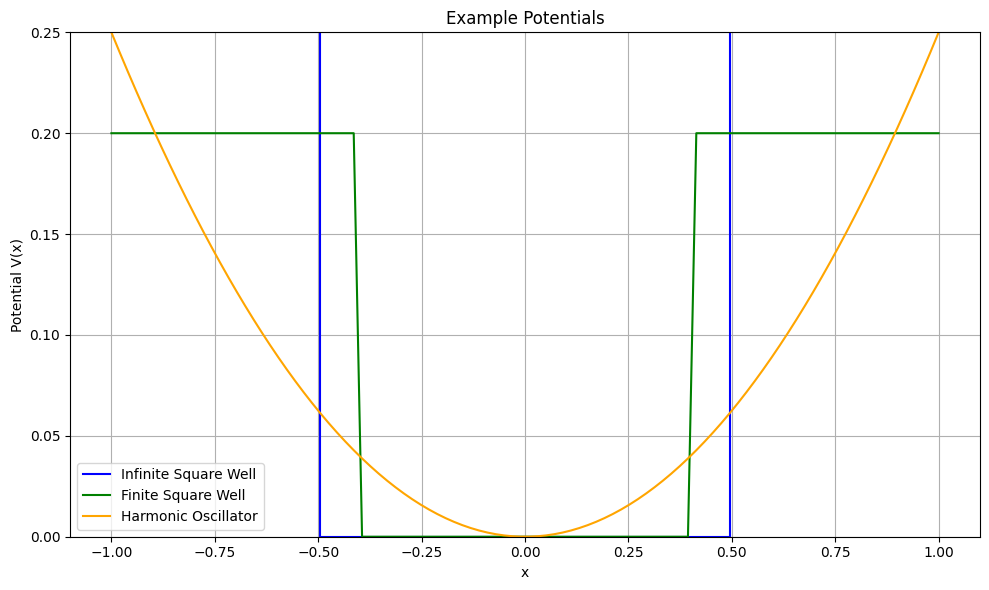

In [8]:
xx = np.linspace(-1, 1, 100)

plt.figure(figsize=(10, 6))
plt.plot(xx, infinite_square_well(xx, L), label="Infinite Square Well", color='blue')
plt.plot(xx, finite_square_well(xx, L, 0.2), label="Finite Square Well", color='green')
plt.plot(xx, quantum_harmonic_oscillator(xx, 0.5), label="Harmonic Oscillator", color='orange')
plt.ylim(0, 0.25)
plt.xlabel("x")
plt.ylabel("Potential V(x)")
plt.title("Example Potentials")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### Solve the steady state schrodinger equation using finite difference method

##kinetic energy matrix:
$
\hat{T} = -\frac{\hbar^2}{2m} \frac{d^2}{dx^2}
\quad \Rightarrow \quad
T = -\frac{\hbar^2}{2m \Delta x^2}
\begin{bmatrix}
-2 & 1 & 0 & 0 & \cdots & 0 \\
1 & -2 & 1 & 0 & \cdots & 0 \\
0 & 1 & -2 & 1 & \cdots & 0 \\
0 & 0 & 1 & -2 & \cdots & 0 \\
\vdots & \vdots & \vdots & \vdots & \ddots & \vdots \\
0 & 0 & 0 & 0 & \cdots & -2
\end{bmatrix}
$


In [9]:
def create_hamiltonian(V, dx):
  N = len(V)
  coeff = hbar**2 / (2 * m * dx**2)
  diagonal = V + 2 * coeff
  off_diagonal = -coeff * np.ones(N - 1)
  return diagonal, off_diagonal

def solve_schrodinger(V, dx):
  diagonal, off_diagonal = create_hamiltonian(V, dx)
  energies, wavefuncs = eigh_tridiagonal(diagonal, off_diagonal)
  return energies,wavefuncs

### Generating the Training Dataset

We generate a dataset of potential profiles and their corresponding ground state energies by solving the Schrödinger equation for the following three types of potentials:
- Infinite square well
- Finite square well
- Harmonic oscillator

In [ ]:
X = []
Y = []

def add_to_dataset(V, dx):
  Es,_ = solve_schrodinger(V, dx)
  X.append(V)
  Y.append(Es)

'''
def add_to_dataset_infinite(V,dx):
    Es,_ = solve_schrodinger(V, dx)
    X.append(V)
    Y.append(Es/10)
'''

def infinite_well(N=1000, L=1.0):

  dx = L / N
  x = np.linspace(0, L, N)
  V = np.zeros(N)
  V[0] = V[-1] = 1e10
  return V, dx

def finite_well(N=1000, L=4.0):
  dx = L / N
  x = np.linspace(0, L, N)
  V0 = 20
  V = np.full(N, V0)
  V[int(0.02*N):int(0.98*N)] = 0
  well_width = 0.5 * L
  return V, dx

def harmonic_oscillator(N=1000, x_max=5.0):
  x = np.linspace(-x_max, x_max, N)
  dx = x[1] - x[0]
  k = 1
  V = 0.5 * k * x**2
  omega = np.sqrt(k / m)
  return V, dx


# Randomizing the order of these potential types and to the dataset
known_potentials = [infinite_well, finite_well, harmonic_oscillator]

for i in range(1200):
  potential_func = np.random.choice(known_potentials)
  if potential_func == infinite_well:
    V, dx = infinite_well()
    #add_to_dataset_infinite(V,dx)
    add_to_dataset(V, dx)
  elif potential_func == finite_well:
    V, dx = finite_well()
    add_to_dataset(V, dx)
  elif potential_func == harmonic_oscillator:
    V, dx = harmonic_oscillator()
    add_to_dataset(V, dx)

## Splitting the Dataset and Scaling Features

We now split the dataset into training and testing sets using an 80–20 ratio.  
Since the input potentials vary across a large numerical range, we apply **standardization** using `StandardScaler` to normalize them.  
This helps improve the performance and convergence of the linear regression model.

In [ ]:
X = np.array(X)
Y = np.array(Y)

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=1)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

'''
Y_train_scaled = scaler.fit_transform(Y_train)
Y_test_scaled = scaler.transform(Y_test)
'''

'\nY_train_scaled = scaler.fit_transform(Y_train)\nY_test_scaled = scaler.transform(Y_test)\n'

In [ ]:
model = LinearRegression()

#model.fit(X_train_scaled, Y_train_scaled)
model.fit(X_train_scaled, Y_train)

#Y_pred_scaled= model.predict(X_test_scaled)
Y_pred = model.predict(X_test_scaled)

## Inverse transform to get original scale
#Y_pred = scaler.inverse_transform(Y_pred_scaled)

## Training the Linear Regression Model

We use **Scikit-learn's `LinearRegression`** to train a model that maps potential profiles to their ground state energy values.  
After training, we evaluate its performance on the test set using:
- **Mean Absolute Error (MAE)**
- **Mean Square Error (MSE)**
- **R² Score (Coefficient of Determination)**

A higher R² and lower MAE indicates a better model fit.


## Error Metrics


*   MAE measures the average magnitude of the errors between predicted and true values. It tells you, on average, how much the predictions deviate from the actual results, regardless of direction (no negative errors).

*   MSE measures the average of the squared errors between predicted and actual values. It penalizes large errors more heavily than small ones due to the squaring, making it more sensitive to outliers.

* The R² score tells us how well the model explains the variance in the actual data.

    R² = 1: perfect prediction

    R² = 0: model does no better than predicting the mean

    R² < 0: model performs worse than just predicting the mean of the target

    
A high R² (close to 1) means the model is capturing the relationship between the potential function and the energy eigenvalues effectively.


## Scatter Plot
Diagonal red dashed line: the ideal "perfect prediction" line where Predicted = Actual.


Error Metrics:
Mean Absolute Error: 0.0000
Mean Squared Error : 0.0000
R² Score           : 1.0000


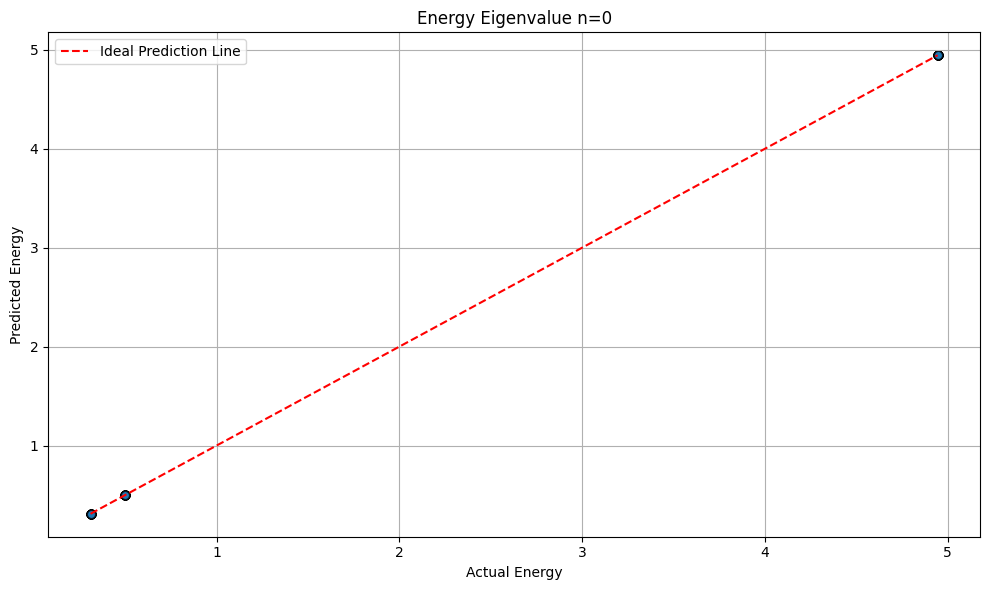

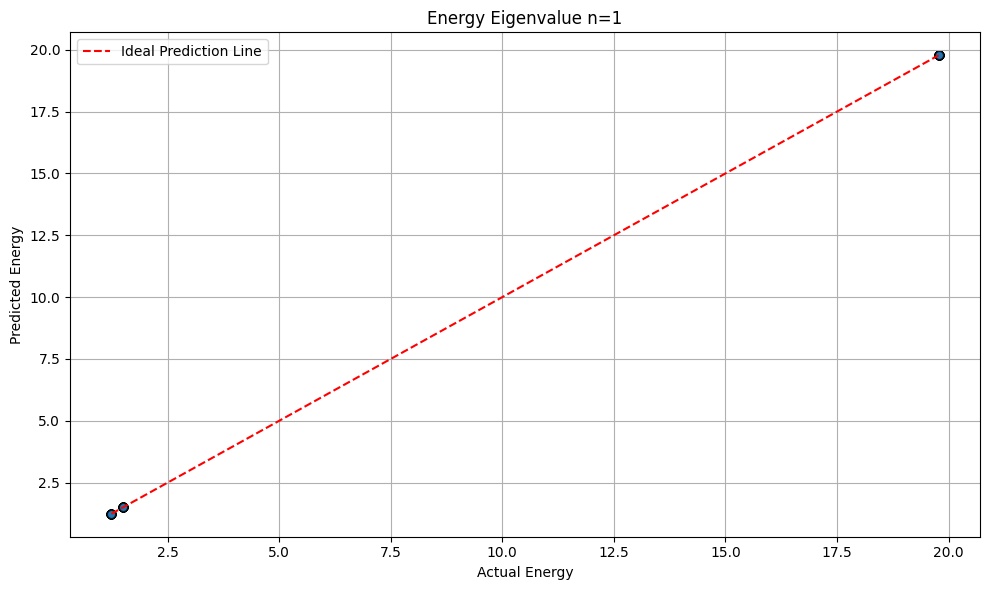

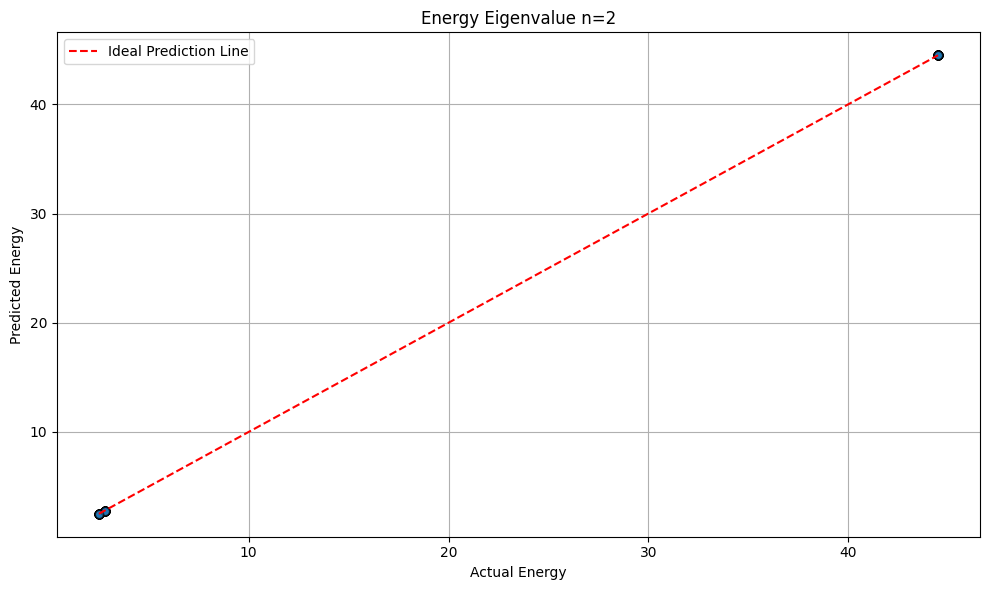

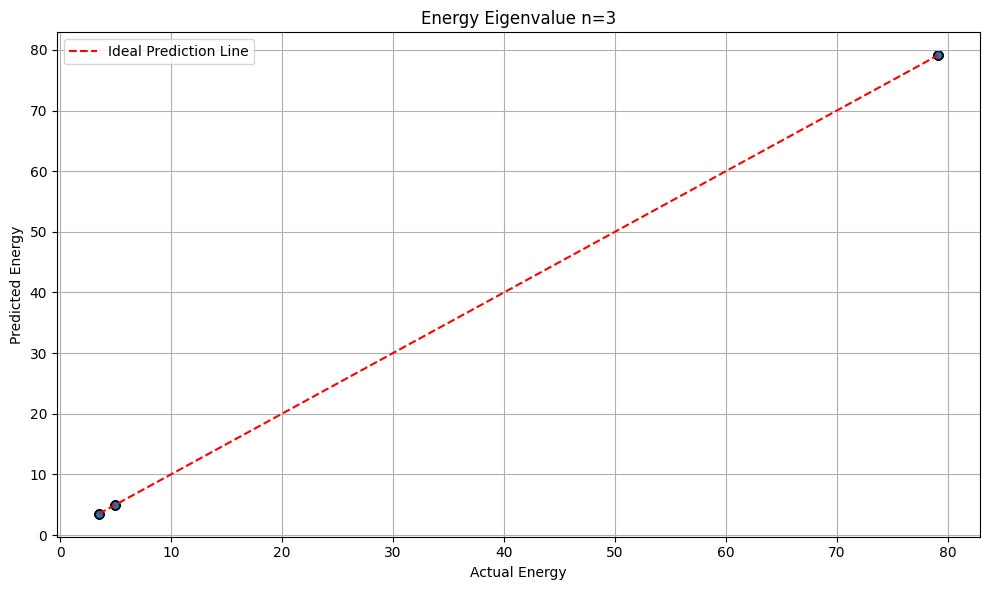

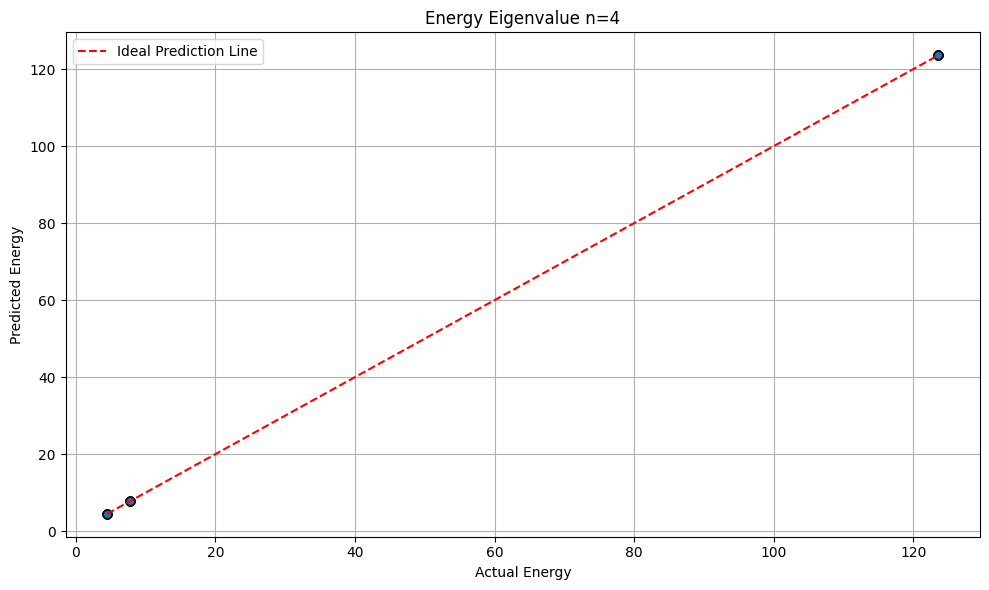

In [ ]:
#mae = mean_absolute_error(Y_test_scaled, Y_pred_scaled)
#mse = mean_squared_error(Y_test_scaled, Y_pred_scaled)

mae = mean_absolute_error(Y_test, Y_pred)
mse = mean_squared_error(Y_test, Y_pred)
r2 = r2_score(Y_test, Y_pred)

print(f"\nError Metrics:")
print(f"Mean Absolute Error: {mae:.4f}")
print(f"Mean Squared Error : {mse:.4f}")
print(f"R² Score           : {r2:.4f}")

# Plotting actual vs predicted
for n in range(5):
    plt.figure(figsize=(10, 6))
    plt.scatter(Y_test[:, n], Y_pred[:, n], alpha=0.6,edgecolors='k')
    plt.plot([min(Y_test[:, n]), max(Y_test[:, n])],
             [min(Y_test[:, n]), max(Y_test[:, n])], 'r--', label='Ideal Prediction Line')
    plt.legend(loc='best')
    plt.title(f"Energy Eigenvalue n={n}")
    plt.xlabel("Actual Energy")
    plt.ylabel("Predicted Energy")
    plt.grid()
    plt.tight_layout()
    plt.show()

### Error trend with energy level index/eigenstate

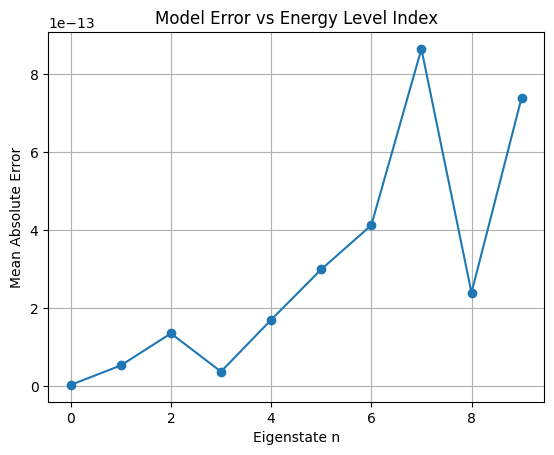

In [ ]:
#per state accuracy trends
mean_abs_error_per_state = np.mean(np.abs(Y_pred - Y_test), axis=0)
plt.plot(range(10), mean_abs_error_per_state[:10], 'o-')
plt.xlabel('Eigenstate n')
plt.ylabel('Mean Absolute Error')
plt.title('Model Error vs Energy Level Index')
plt.grid(True)
plt.show()

## Plotting Actual Values vs Predicted Values

black dashes - actual values


red dots - predicted values

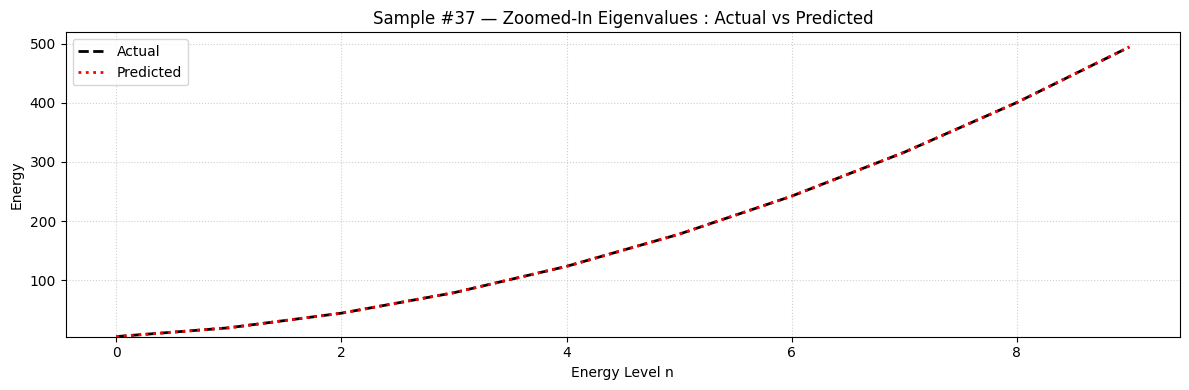

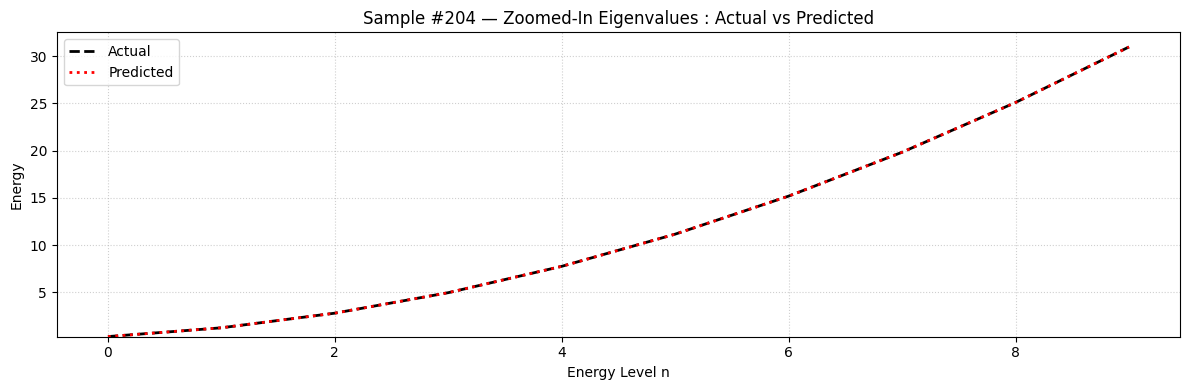

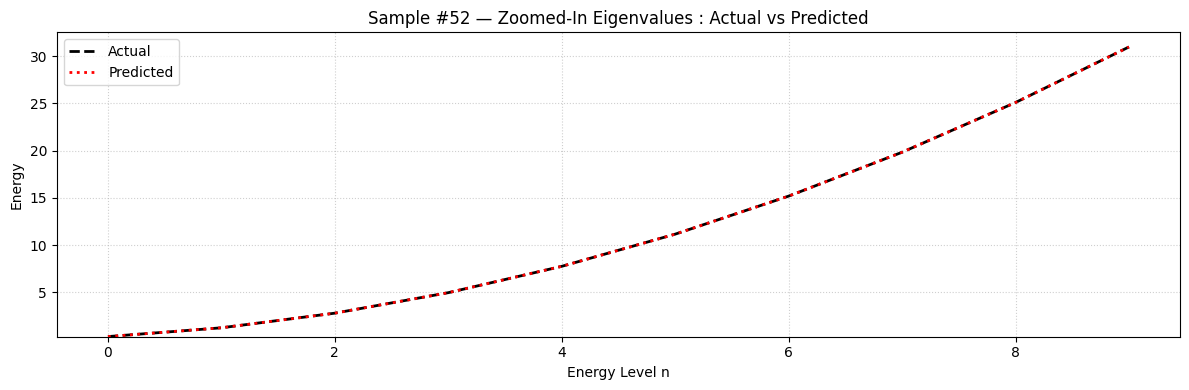

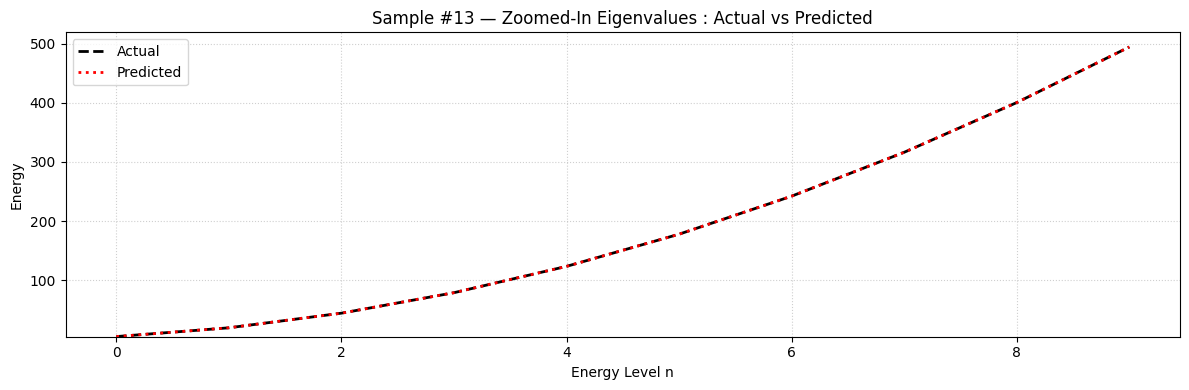

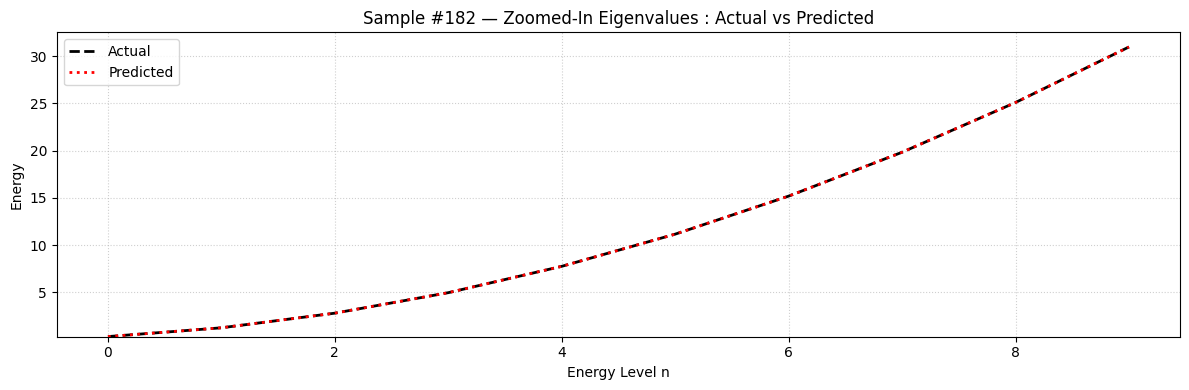

In [ ]:
num_plot = 5
indices = np.random.choice(len(Y_test), num_plot, replace=False)

for idx in indices:
    actual = Y_test[idx][:10]      # Only first 10 energy levels
    predicted = Y_pred[idx][:10]    # Only first 10 energy levels

    # Calculating energy range with small padding for zoom
    min_energy = min(np.min(actual), np.min(predicted)) * 0.95
    max_energy = max(np.max(actual), np.max(predicted)) * 1.05

    plt.figure(figsize=(12, 4))  # Wider figure
    plt.plot(range(len(actual)), actual, 'k--', linewidth=2.0, label='Actual')
    plt.plot(range(len(predicted)), predicted, 'r:', linewidth=2.0, label='Predicted')

    plt.title(f"Sample #{idx} — Zoomed-In Eigenvalues : Actual vs Predicted")
    plt.xlabel("Energy Level n")
    plt.ylabel("Energy")
    plt.ylim(min_energy, max_energy)
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.legend()
    plt.tight_layout()
    plt.show()

## Complexity Features
1. Roughness measures how rapidly a potential V(x) changes across space. It is computed as the standard deviation of the potential’s gradient, std(∇V).
A smoother potential (like a harmonic oscillator) has low roughness, while jagged or sharply varying potentials exhibit high roughness.

2. Symmetry quantifies how mirror-symmetric a potential is with respect to its center (around x=0.5). It is measured using the L1 norm (sum of absolute differences) between V(x) and its flipped version V(−x).Perfectly symmetric potentials like the harmonic oscillator have zero symmetry score, while asymmetric ones score higher. Since eigenfunctions and energies can be sensitive to symmetry (especially for even/odd solutions), asymmetry can introduce greater prediction errors if not well modeled.

3. Number of Minima: This feature counts the number of local minima in the potential — i.e., the number of "wells" or trapping regions for a particle. It is obtained by finding peaks in the inverted potential, −V(x).
A single well (like an infinite square well) will have one minimum, while more complex landscapes (e.g., double wells or multi-well systems) will have multiple minima. More minima generally imply higher spatial complexity, potentially requiring more expressive models to accurately predict energy eigenvalues.

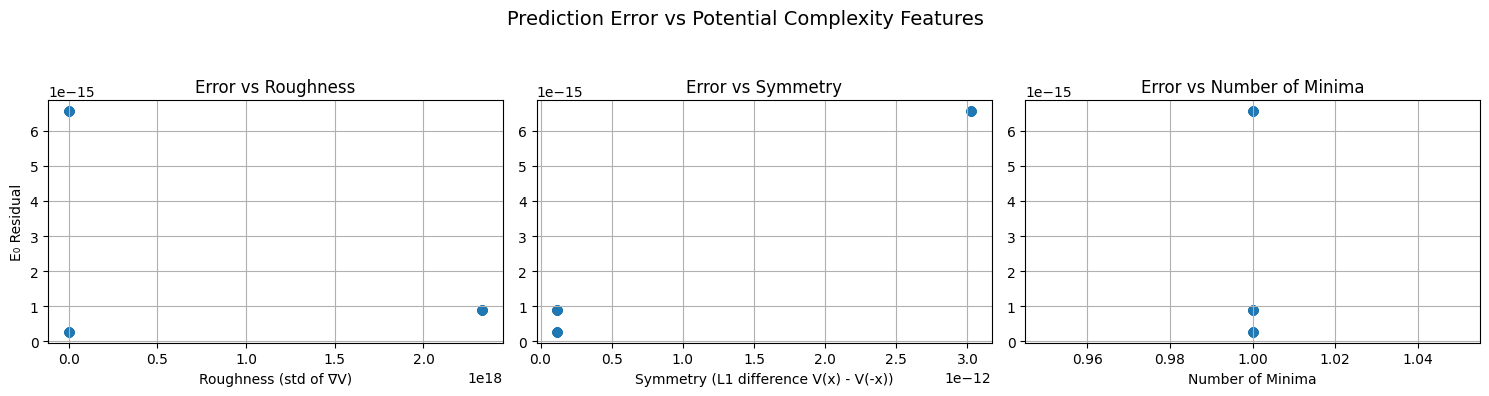

In [ ]:
# Initializing lists to store complexity features
roughness_list = []
symmetry_list = []
num_minima_list = []

# Looping over each test potential
for V in X_test:

    V_actual = scaler.inverse_transform([V])[0] if hasattr(scaler, 'inverse_transform') else V

    # Feature 1: Roughness = std of gradient
    roughness = np.std(np.gradient(V_actual))

    # Feature 2: Symmetry = L1 norm of V(x) - V(-x)
    symmetry = np.sum(np.abs(V_actual - V_actual[::-1]))

    # Feature 3: Number of minima (peaks in -V)
    minima_indices, _ = find_peaks(-V_actual)
    num_minima = len(minima_indices)

    roughness_list.append(roughness)
    symmetry_list.append(symmetry)
    num_minima_list.append(num_minima)

# Residuals for E0
residual_E0 = np.abs(Y_pred[:, 0] - Y_test[:, 0])

# Converting to arrays
roughness_list = np.array(roughness_list)
symmetry_list = np.array(symmetry_list)
num_minima_list = np.array(num_minima_list)

# Plotting error vs each complexity metric
plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
plt.scatter(roughness_list, residual_E0, alpha=0.7)
plt.xlabel("Roughness (std of ∇V)")
plt.ylabel("E₀ Residual")
plt.title("Error vs Roughness")
plt.grid(True)

plt.subplot(1, 3, 2)
plt.scatter(symmetry_list, residual_E0, alpha=0.7)
plt.xlabel("Symmetry (L1 difference V(x) - V(-x))")
plt.title("Error vs Symmetry")
plt.grid(True)

plt.subplot(1, 3, 3)
plt.scatter(num_minima_list, residual_E0, alpha=0.7)
plt.xlabel("Number of Minima")
plt.title("Error vs Number of Minima")
plt.grid(True)

plt.suptitle("Prediction Error vs Potential Complexity Features", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

## A Correlation heatmap comparing all the parameters discussed till now

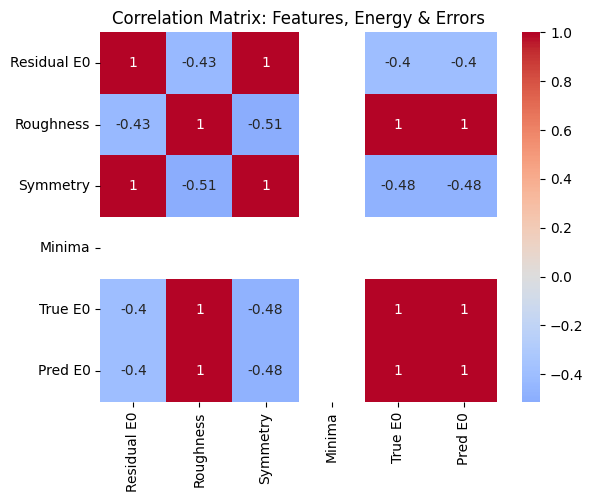

In [ ]:
#corelation heatmap
df_corr = pd.DataFrame({
    "Residual E0": residual_E0,
    "Roughness": roughness_list,
    "Symmetry": symmetry_list,
    "Minima": num_minima_list,
    "True E0": Y_test[:, 0],
    "Pred E0": Y_pred[:, 0]
})

sns.heatmap(df_corr.corr(), annot=True, cmap="coolwarm", center=0)
plt.title("Correlation Matrix: Features, Energy & Errors")
plt.show()

# Residuals

Residuals provide direct insight into how accurate a model's predictions are. Analyzing them helps:

1. Evaluate Accuracy:
If residuals are small and centered around zero, the model is accurate.Large residuals indicate poor predictions.

2. Detect Bias:
Consistently positive or negative residuals suggest systematic over- or under-prediction.

3. Assess Variance Across Outputs:
For example, if residuals grow larger for higher-energy eigenstates, the model struggles more with those cases.

4. Check Distribution:
A normal, symmetric distribution centered at zero indicates a well-behaved model.Skewed or multi-modal distributions can signal problems or missing complexity in the model.




    

In [ ]:
residuals = Y_test - Y_pred  # shape: (N_samples, N_states)
residual_E0 = residuals[:, 0]  # first eigenstate residuals

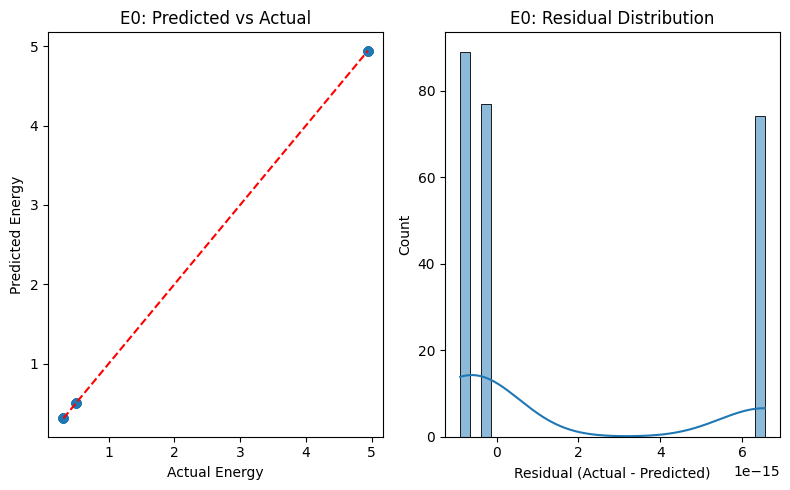

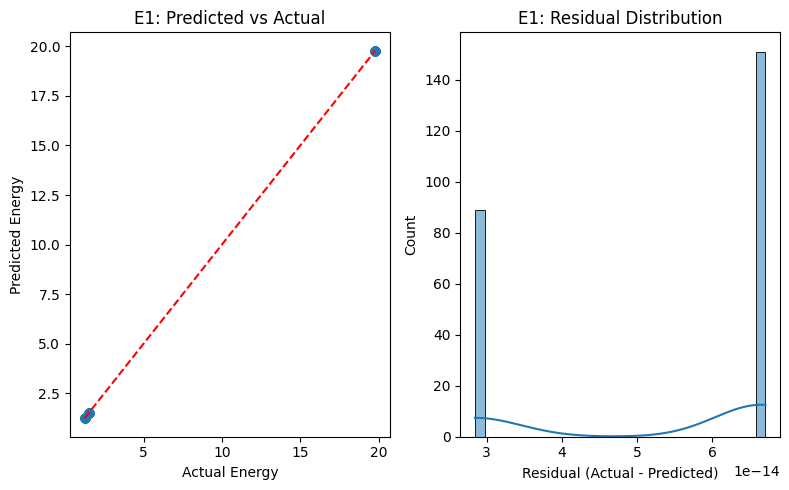

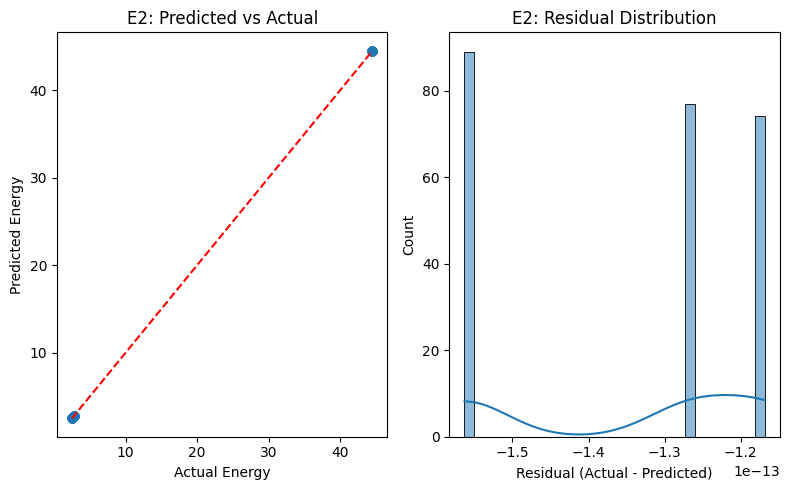

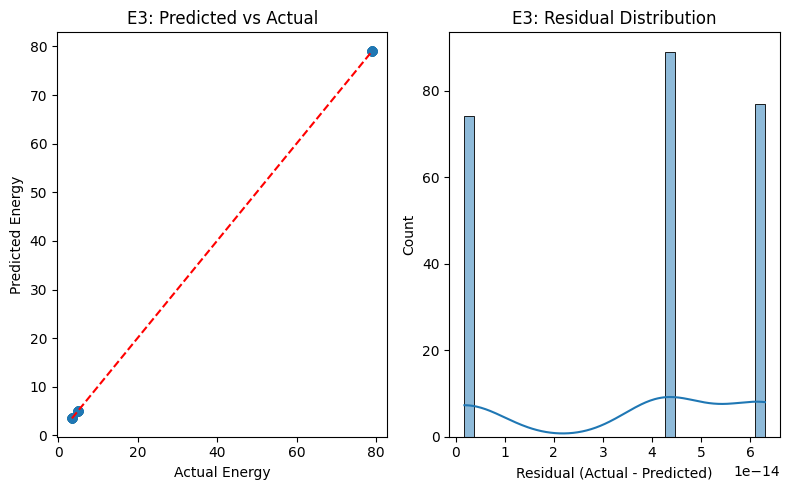

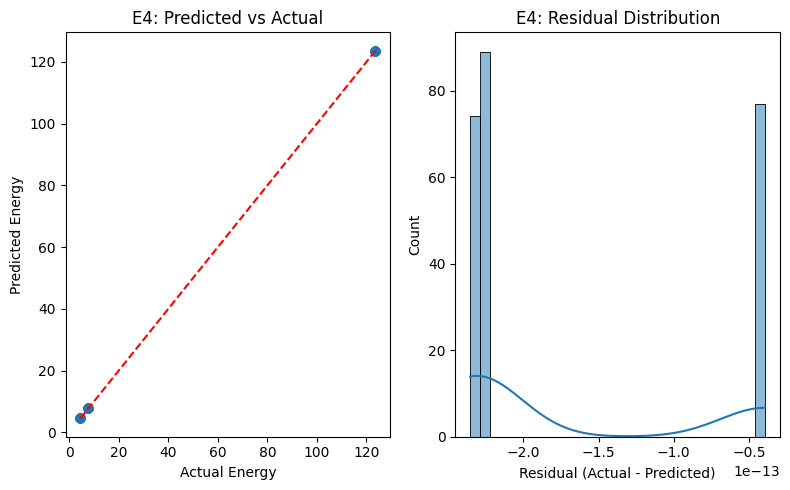

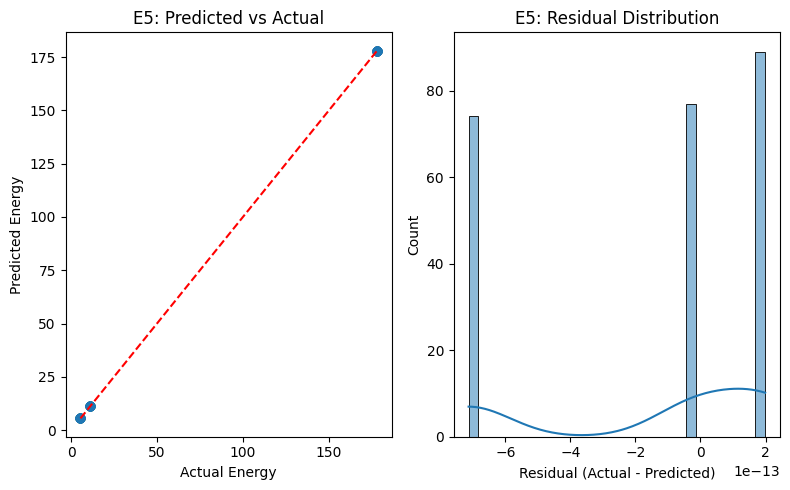

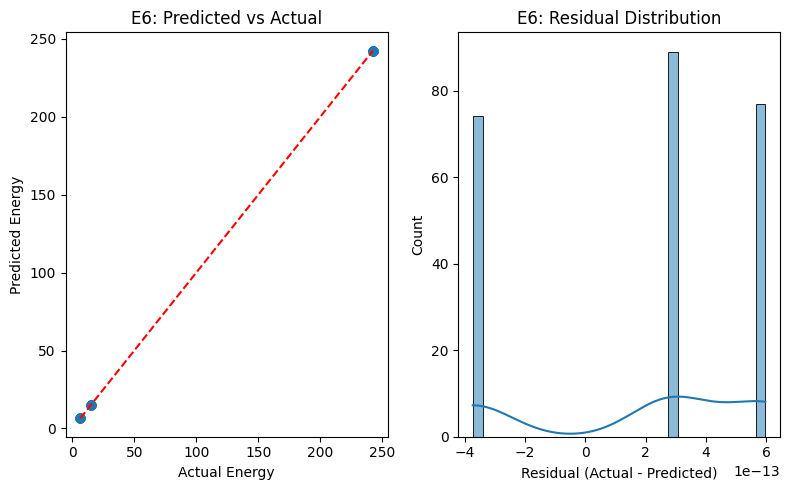

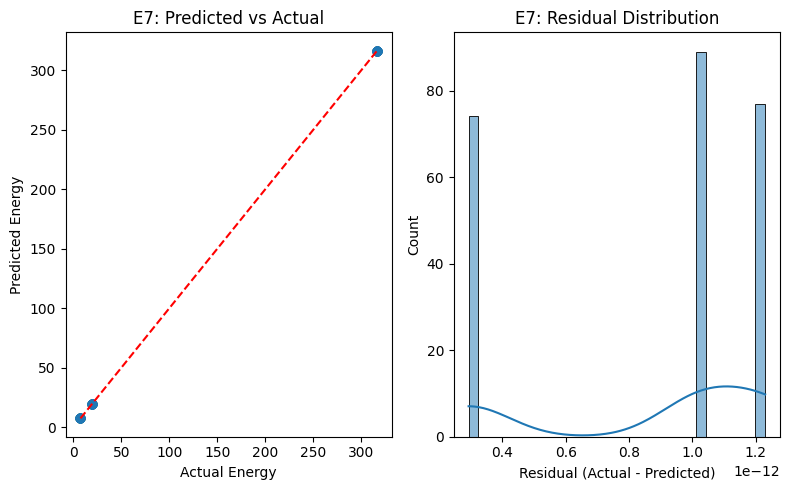

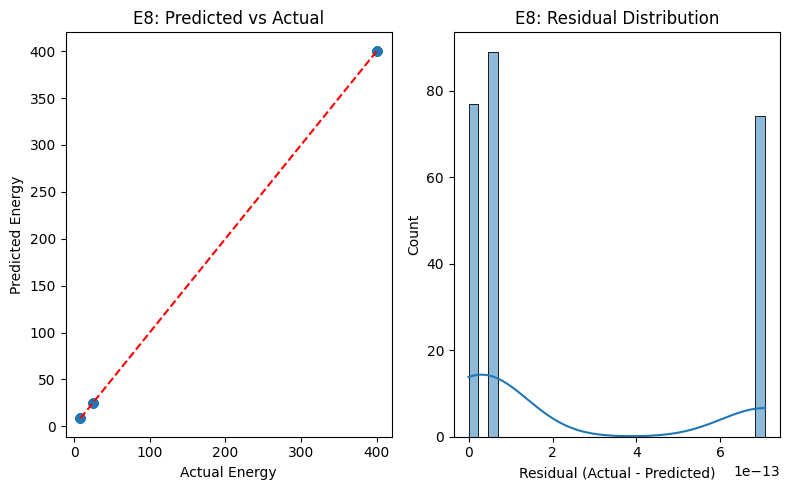

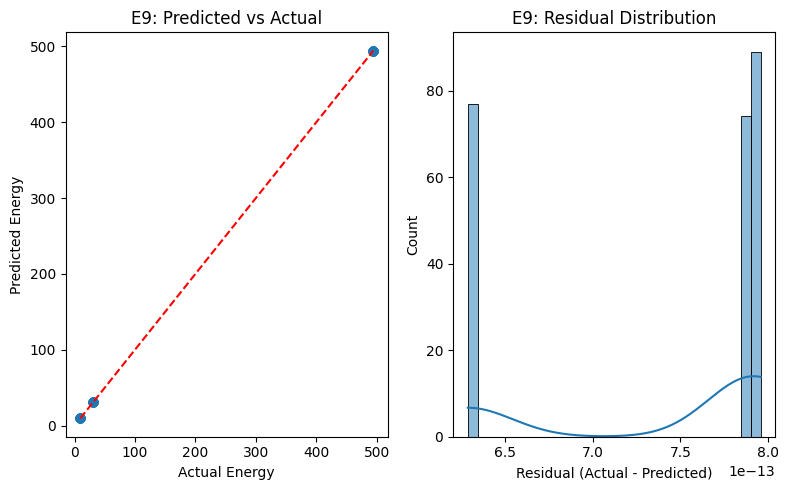

In [ ]:
for n in range(10):  # Only looping over the first 10 energy levels
    plt.figure(figsize=(8, 5))

    # Predicted vs Actual Scatter Plot
    plt.subplot(1, 2, 1)
    plt.scatter(Y_test[:, n], Y_pred[:, n], alpha=0.7)
    plt.plot([Y_test[:, n].min(), Y_test[:, n].max()],
             [Y_test[:, n].min(), Y_test[:, n].max()], 'r--')
    plt.xlabel("Actual Energy")
    plt.ylabel("Predicted Energy")
    plt.title(f"E{n}: Predicted vs Actual")

    # Residual Distribution
    plt.subplot(1, 2, 2)
    residuals = Y_test[:, n] - Y_pred[:, n]
    sns.histplot(residuals, kde=True, bins=30)
    plt.title(f"E{n}: Residual Distribution")
    plt.xlabel("Residual (Actual - Predicted)")

    plt.tight_layout()
    plt.show()

### Testing on an Unseen Potential

To further validate the generalization of our model, we now introduce a quartic potential
(not included in the training data) and compare predicted vs. actual eigenvalues.
We also compute percentage errors and present them in tabular form.


In [ ]:
# Defining quartic potential: V(x) = a * x^4
def quartic_potential(N=1000, x_max=0.5, a=0.1):
    x = np.linspace(-x_max, x_max, N)
    dx = x[1] - x[0]
    V = a * x**4
    return V, dx

# Generating unseen potential data
V_unseen, dx_unseen = quartic_potential()
E_unseen, _ = solve_schrodinger(V_unseen, dx_unseen)

# Preparing input for model prediction
V_scaled = scaler.transform([V_unseen])
E_pred_unseen = model.predict(V_scaled)[0]

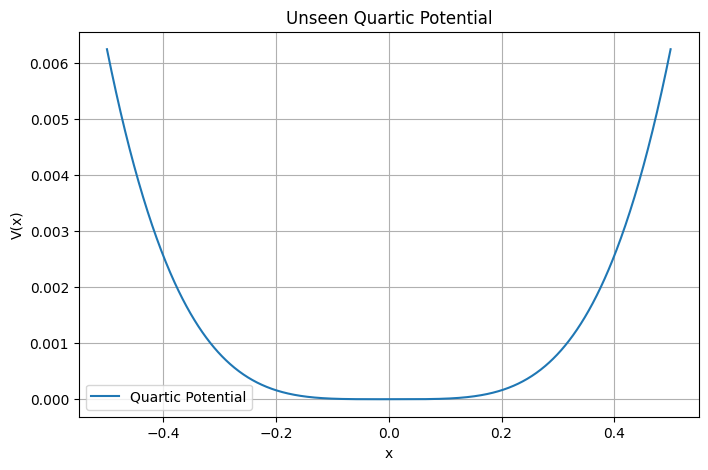

In [ ]:
# Plotting potential
plt.figure(figsize=(8,5))
plt.plot(np.linspace(-0.5,0.5,1000), V_unseen, label="Quartic Potential")
plt.xlabel("x")
plt.ylabel("V(x)")
plt.title("Unseen Quartic Potential")
plt.grid(True)
plt.legend()
plt.show()

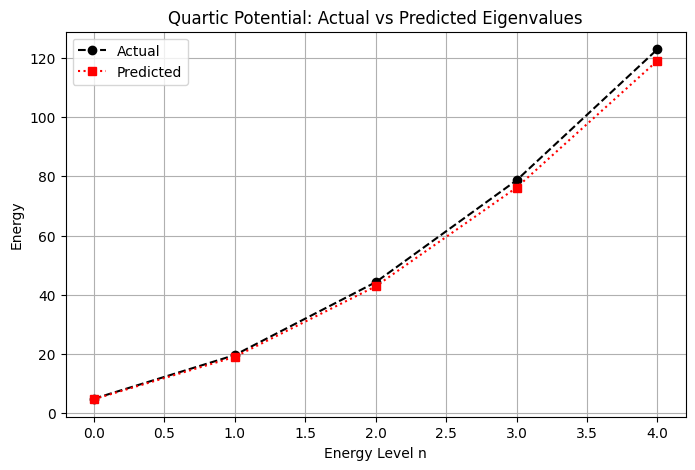

In [ ]:
# Plotting energy progression with n for actual and predicted eigenvalues
n_levels = 5
plt.figure(figsize=(8,5))
plt.plot(range(n_levels), E_unseen[:n_levels], 'k--o', label="Actual")
plt.plot(range(n_levels), E_pred_unseen[:n_levels], 'r:s', label="Predicted")
plt.xlabel("Energy Level n")
plt.ylabel("Energy")
plt.title("Quartic Potential: Actual vs Predicted Eigenvalues")
plt.grid(True)
plt.legend()
plt.show()

In [ ]:
# Creating dataframe with percentage errors
df_errors = pd.DataFrame({
    "n": np.arange(1, n_levels+1),
    "Reference Energy": E_unseen[:n_levels],
    "Predicted Energy": E_pred_unseen[:n_levels],
    "Percentage Error (%)": np.abs((E_pred_unseen[:n_levels]-E_unseen[:n_levels]) / E_unseen[:n_levels])*100
})

display(df_errors)

# Generating LaTeX table code
latex_table = df_errors.to_latex(index=False, float_format="%.6f")
print(latex_table)

,n,Reference Energy,Predicted Energy,Percentage Error (%)
0,1,4.915357,4.762051,3.118927
1,2,19.661064,19.047667,3.119855
2,3,44.236590,42.856217,3.120434
3,4,78.641712,76.187461,3.120801
4,5,122.876199,119.041066,3.121136


\begin{tabular}{rrrr}
\toprule
n & Reference Energy & Predicted Energy & Percentage Error (%) \\
\midrule
1 & 4.915357 & 4.762051 & 3.118927 \\
2 & 19.661064 & 19.047667 & 3.119855 \\
3 & 44.236590 & 42.856217 & 3.120434 \\
4 & 78.641712 & 76.187461 & 3.120801 \\
5 & 122.876199 & 119.041066 & 3.121136 \\
\bottomrule
\end{tabular}

